### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P249 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

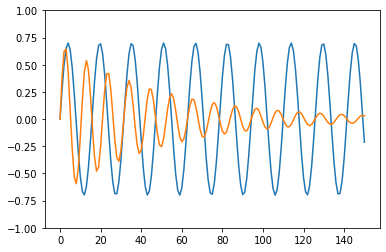

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 8

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

249

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.00023601006629428285   1.8117256164550781 sec      
199: 0.0001395507352315296   2.5943098068237305 sec       
299: 9.897234359440293e-05   3.3401734828948975 sec       
399: 7.859721343483997e-05   4.108381509780884 sec       
499: 0.00013562702872578229   4.857891082763672 sec       
599: 6.295601654764894e-05   5.535118103027344 sec       
699: 6.347541724369054e-05   6.291910886764526 sec        
799: 5.246164694366954e-05   7.07231330871582 sec         
899: 8.327125488597079e-05   7.804233074188232 sec        
999: 4.7904295541250754e-05   8.496366262435913 sec      
1099: 0.00012550477813319668   9.157296895980835 sec      
1199: 4.237569216493418e-05   9.816609621047974 sec       
1299: 3.8213601017250916e-05   10.469264507293701 sec      
1399: 6.398006631726854e-05   11.276057720184326 sec       
1499: 0.00019096090191683218   12.000974416732788 sec      
1599: 3.7426136249176706e-05   12.658531427383423 sec      
1699: 3.581071739469655e-05   13.4282

26399: 6.27638203184946e-05   195.84349703788757 sec        
learning rate: 0.025
26499: 3.7318153424183105e-05   196.6492462158203 sec       
26599: 3.438862419373813e-05   197.4309811592102 sec        
26699: 3.3530564760337054e-05   198.2330470085144 sec       
26799: 3.327561571603029e-05   199.0520260334015 sec        
26899: 3.3187493536022806e-05   199.87086582183838 sec      
26999: 3.3139657383308056e-05   200.68196988105774 sec      
learning rate: 0.2
27099: 0.0007398332751541695   201.56568002700806 sec      
27199: 0.0002313890003184836   202.26275753974915 sec       
27299: 0.00013773782129151518   203.00583362579346 sec      
27399: 0.00010848536101339729   203.75329208374023 sec      
27499: 9.20898987351006e-05   204.5096378326416 sec         
27599: 8.293747951170006e-05   205.22295212745667 sec      
27699: 7.687302393134387e-05   206.01199388504028 sec      
27799: 7.180302553325362e-05   206.7995822429657 sec       
27899: 6.710011453312102e-05   207.57733988761902

52499: 3.4007110758016035e-05   389.4449026584625 sec       
52599: 3.372488094833223e-05   390.15654826164246 sec       
52699: 3.3548142489524463e-05   390.8382520675659 sec       
52799: 3.343174806002745e-05   391.61261653900146 sec       
learning rate: 0.2
52899: 0.00047016603770513887   392.34210181236267 sec      
52999: 0.00020081531799954173   393.07247161865234 sec      
53099: 0.00017901420014020903   393.80395007133484 sec      
53199: 0.00011904975248153161   394.5096528530121 sec       
53299: 9.758972140889497e-05   395.20122265815735 sec       
53399: 7.882547184450871e-05   395.91768980026245 sec      
53499: 6.376029032813497e-05   396.6853029727936 sec       
53599: 5.164876964213909e-05   397.4251902103424 sec        
53699: 4.341658132721494e-05   398.123899936676 sec         
53799: 3.8985451991433044e-05   398.8526532649994 sec       
53899: 4.3211351529505134e-05   399.5487174987793 sec       
53999: 3.6900714029205996e-05   400.24466609954834 sec      
54099: 

78799: 0.00024568999570686375   580.6041994094849 sec      
78899: 0.0015035108863132134   581.4503610134125 sec       
78999: 0.00024741181325061557   582.3009793758392 sec      
79099: 0.00023577842705537185   583.0603115558624 sec      
79199: 0.0002293891363918748   583.8183162212372 sec       
79299: 0.0002236152423837978   584.5784187316895 sec       
79399: 0.0002812069062781471   585.3556718826294 sec       
79499: 0.00022823819314762492   586.1061165332794 sec      
79599: 0.0002128969270019293   586.891375541687 sec        
79699: 0.00020461434068589162   587.6471452713013 sec      
79799: 0.0001965064781448815   588.442756652832 sec        
79899: 0.00018767044460070607   589.1841218471527 sec      
79999: 0.0009694322077540201   589.99272108078 sec         
80099: 0.00018345013600922918   590.7394938468933 sec      
80199: 0.00017059577360069585   591.4708843231201 sec      
80299: 0.00016133265147398859   592.2425539493561 sec      
80399: 0.00015283526924062639   593.0079

105499: 0.0001237949800057359   792.1969327926636 sec       
105599: 7.271625556665165e-05   792.9605915546417 sec       
105699: 5.6310551706227735e-05   793.6777813434601 sec      
105799: 5.126397468670863e-05   794.4321336746216 sec       
105899: 4.8555346823934215e-05   795.1786959171295 sec      
105999: 4.645464487563996e-05   795.9386780261993 sec       
106099: 4.46950451472493e-05   796.7440214157104 sec        
106199: 4.323670026866309e-05   797.5046970844269 sec       
106299: 4.203788886088846e-05   798.2444789409637 sec       
106399: 4.102817231027081e-05   799.0415201187134 sec       
106499: 4.0156763756296996e-05   799.7793440818787 sec      
106599: 4.768089888581967e-05   800.6100409030914 sec       
106699: 3.900240152913617e-05   801.3955144882202 sec       
106799: 3.8259162305847074e-05   802.1655824184418 sec      
106899: 3.765250167612842e-05   803.0022912025452 sec       
106999: 3.713143973888931e-05   803.8400774002075 sec       
107099: 3.66681769944916

131599: 8.63706587444918e-05   991.5659873485565 sec        
131699: 4.500728533489515e-05   992.3174273967743 sec       
131799: 4.137059013613957e-05   993.0732674598694 sec       
131899: 7.572415247437556e-05   993.8134713172913 sec       
131999: 3.7576315496147003e-05   994.5816359519958 sec      
132099: 0.00013184224880597524   995.3311383724213 sec      
132199: 3.771016089577777e-05   996.0586984157562 sec       
132299: 3.6036729312941357e-05   996.7957558631897 sec      
132399: 0.0009344103012886017   997.5830495357513 sec       
132499: 3.588425907277745e-05   998.359931230545 sec        
132599: 0.00019134617093549935   999.122994184494 sec       
132699: 3.565663761762479e-05   999.8531203269958 sec       
132799: 5.9354277615527586e-05   1000.6800417900085 sec      
132899: 3.630068890965374e-05   1001.531622171402 sec        
132999: 3.5544748424306494e-05   1002.3469910621643 sec      
133099: 7.523227650614994e-05   1003.1194539070129 sec       
133199: 0.0004593460

157199: 3.453516643313516e-05   1186.9380867481232 sec       
157299: 3.424940629384562e-05   1187.6698315143585 sec       
157399: 3.403786095066922e-05   1188.4237117767334 sec       
157499: 3.387431554980681e-05   1189.1920676231384 sec       
learning rate: 0.2
157599: 0.0006236184670384626   1189.950362443924 sec       
157699: 0.00023657637193010402   1190.6831142902374 sec      
157799: 0.00014299295567818548   1191.424197435379 sec       
157899: 0.00010932915400943609   1192.1766595840454 sec      
157999: 8.921164480723905e-05   1192.948338508606 sec        
158099: 7.670248701645617e-05   1193.6811578273773 sec      
158199: 6.790206871575916e-05   1194.4430615901947 sec      
158299: 6.07113547564009e-05   1195.18345785141 sec          
158399: 5.478200298307795e-05   1195.9397161006927 sec       
158499: 5.002762024798669e-05   1196.6885573863983 sec       
158599: 4.628440806703908e-05   1197.423893213272 sec        
158699: 4.335808149154331e-05   1198.1725301742554 sec

183299: 0.00010263780666276129   1385.1267261505127 sec      
183399: 6.851088053837841e-05   1385.8637716770172 sec       
183499: 4.905354623289728e-05   1386.6549651622772 sec       
learning rate: 0.025
183599: 4.289255153592175e-05   1387.4521832466125 sec       
183699: 3.788469757114878e-05   1388.183965921402 sec        
183799: 3.588570818590203e-05   1388.9148259162903 sec       
183899: 3.493291752555634e-05   1389.6708862781525 sec       
183999: 3.446532449979358e-05   1390.4422211647034 sec       
184099: 3.419904741357188e-05   1391.1810462474823 sec       
184199: 3.4025445700826113e-05   1391.9366250038147 sec      
184299: 3.3899458041972734e-05   1392.664920091629 sec       
learning rate: 0.2
184399: 0.0006313202356688376   1393.445644378662 sec       
184499: 0.0002589480043444922   1394.1474568843842 sec       
184599: 0.00017449728433399333   1394.8747861385345 sec      
184699: 0.00013582785595947036   1395.611671924591 sec       
184799: 0.00011014132128967663 

208799: 3.461041662370718e-05   1603.2988512516022 sec       
208899: 3.355605423818008e-05   1604.2096898555756 sec       
208999: 3.377210086483032e-05   1605.1136786937714 sec       
209099: 3.428354966624552e-05   1606.0096445083618 sec       
209199: 3.4067825603428434e-05   1606.9220066070557 sec      
learning rate: 0.05
209299: 8.887397261039374e-05   1607.8443212509155 sec       
learning rate: 0.025
209399: 3.8984391069901165e-05   1608.7349028587341 sec      
209499: 3.4272997350987726e-05   1609.6356999874115 sec      
learning rate: 0.0125
209599: 3.372103511013682e-05   1610.537023305893 sec        
209699: 3.3372509903159604e-05   1611.492867231369 sec       
209799: 3.324774607758033e-05   1612.4254562854767 sec       
209899: 3.318617761534542e-05   1613.361938714981 sec        
209999: 3.319320518593339e-05   1614.2086374759674 sec       
210099: 3.4566137104183835e-05   1615.0744664669037 sec      
210199: 3.312274450973507e-05   1615.9419531822205 sec       
210299:

In [23]:
minLoss

Array(3.30741377e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

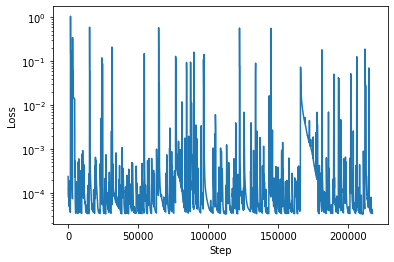

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

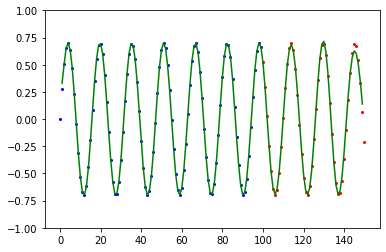

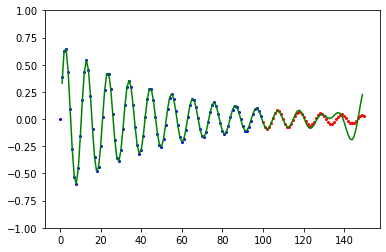

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

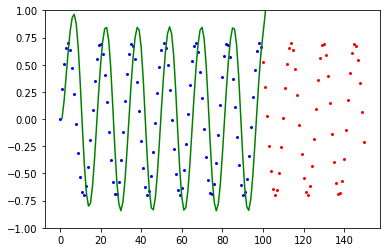

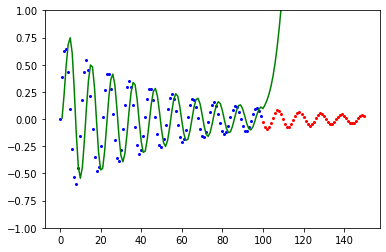

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[192900,
 Array(3.38207354e-05, dtype=float64),
 Array(2.23586241e-05, dtype=float64),
 [((Array([[-0.13618509,  1.46467643,  1.51039848, -0.68056458,  1.06912397,
             0.73099617,  0.19412531,  0.60037135]], dtype=float64),
    Array([[ 2.40702241,  2.48184906, -0.72198725, -0.21453493, -0.38367383,
             0.27947277, -0.6283791 ,  0.57289822],
           [-0.91287751,  0.77193915,  0.12909595,  0.89393615, -2.09396638,
             0.02140717, -1.21877492,  1.17274166],
           [-1.21902557, -0.51539607, -1.32627669, -2.15043046, -2.32531943,
             0.86819728, -1.45560524, -2.63958862],
           [ 0.64277862,  1.74771867, -1.48969586, -2.48291755,  1.11520201,
             0.24638273,  0.34706644,  1.0083556 ],
           [ 1.29537131, -1.00713126, -0.39325196,  1.8512899 , -1.74355009,
             0.6008062 ,  3.74817016,  0.852312  ],
           [ 1.09119316, -2.21958389,  0.52114708, -0.82646148, -1.36572286,
            -0.83561922,  0.13647563, -0.2020

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

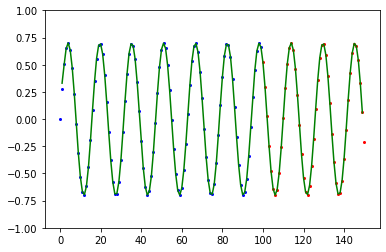

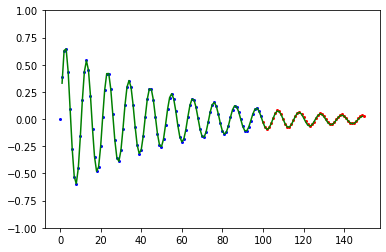

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [192900, Array(3.38207354e-05, dtype=float64), Array(2.23586241e-05, dtype=float64)]
2500 0.13143355590678094 0.0021111486051183116


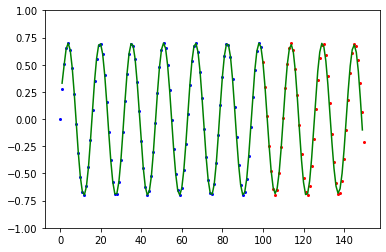

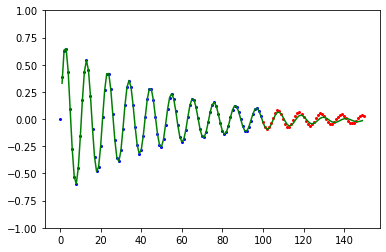

4800 0.013712816882002037 0.013406574664960322


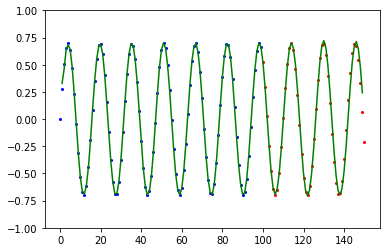

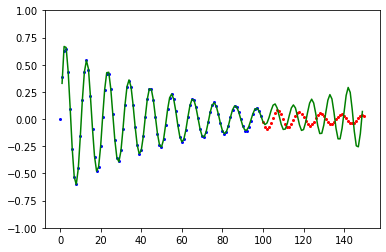

7200 3.36847992464941e-05 0.0003160318032544126


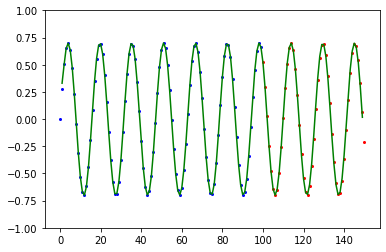

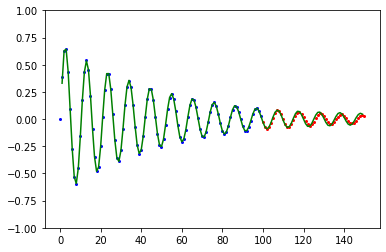

9800 3.417557070074038e-05 0.0012641886900740887


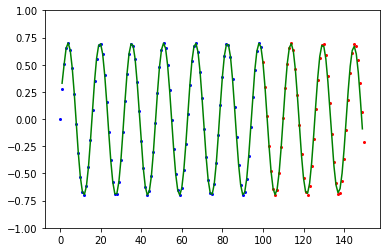

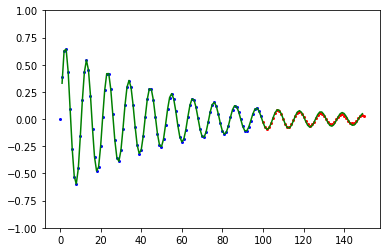

15100 3.3578942704433405e-05 4.383364908913161e-05


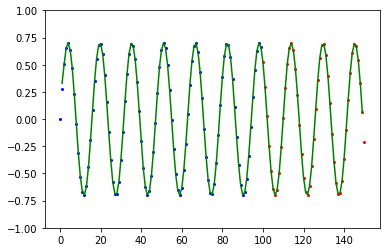

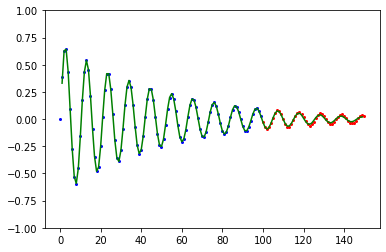

19100 3.420528142231008e-05 0.0024347351153366776


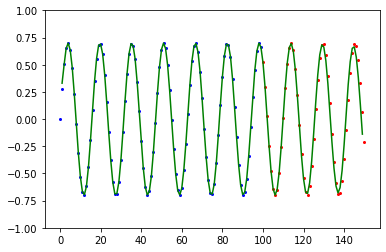

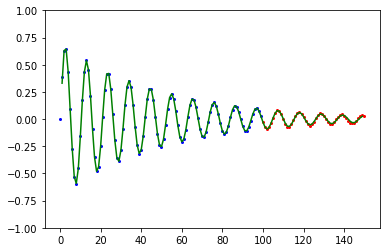

22900 3.376674758761705e-05 0.0006602903548588997


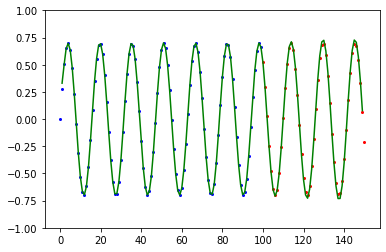

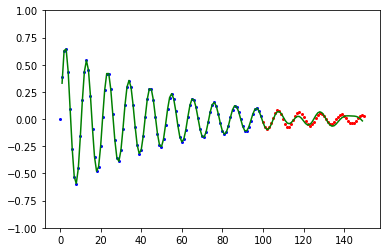

24800 0.0867112398661271 0.24039441062077946


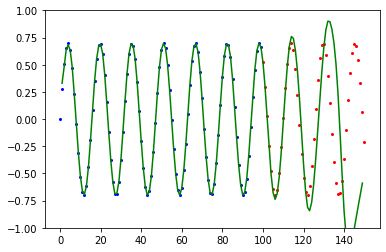

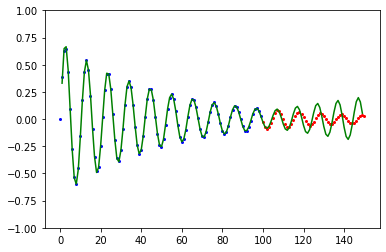

27000 3.3139657383308056e-05 0.00012137066869197912


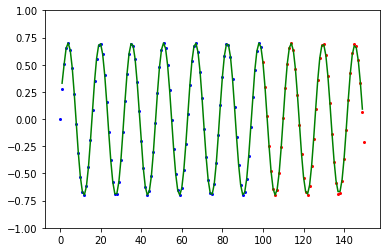

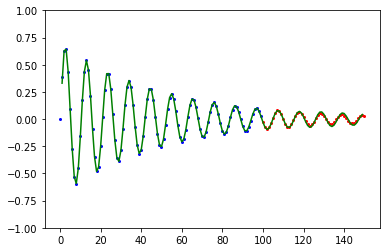

30800 3.416202434971929e-05 0.0005623889734767222


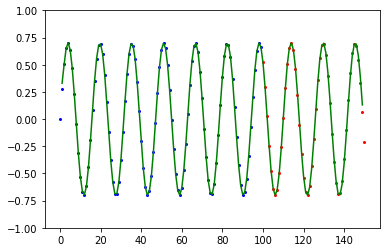

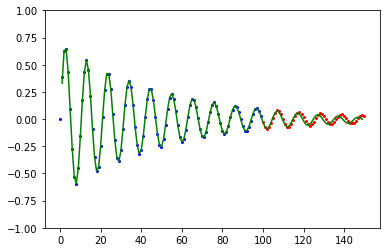

38400 3.3326929248105004e-05 0.00014141859864252857


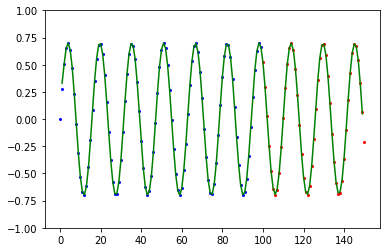

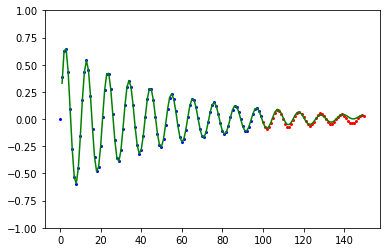

41000 3.3549655445891925e-05 9.080506200162066e-05


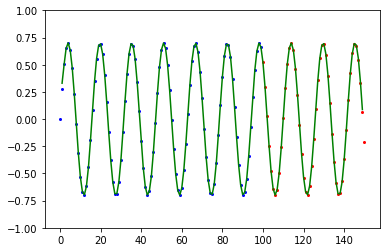

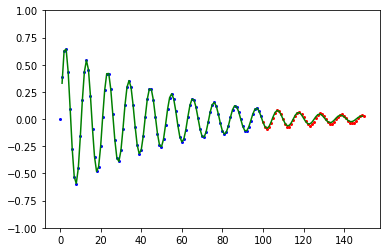

43300 3.334962562962064e-05 2.4097324316927416e-05


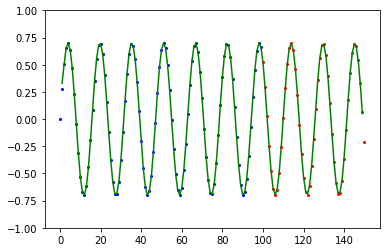

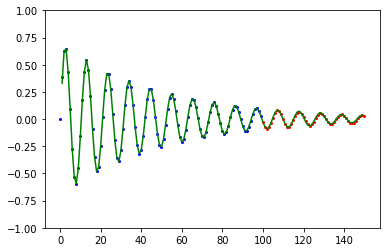

48600 3.404339818760131e-05 0.015166583291724258


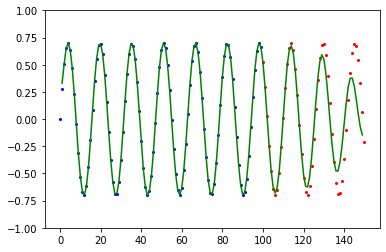

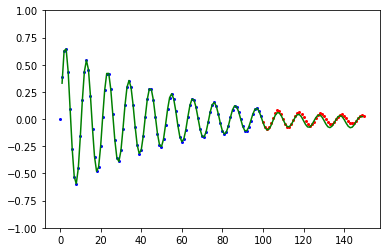

52800 3.343174806002745e-05 0.029223840549028064


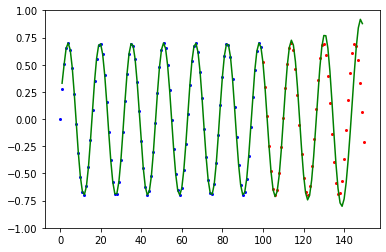

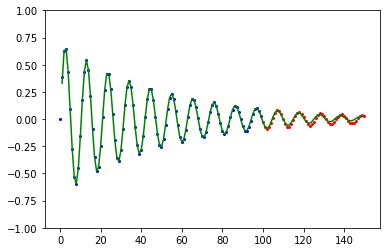

56700 3.3507082704237504e-05 0.010669162382158544


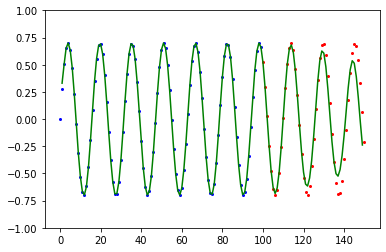

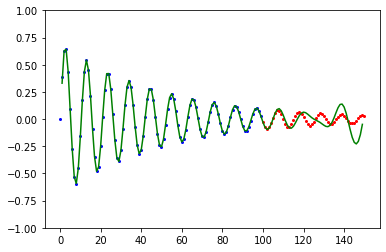

59600 3.370839625293199e-05 0.003076345052065877


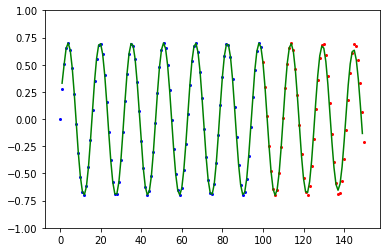

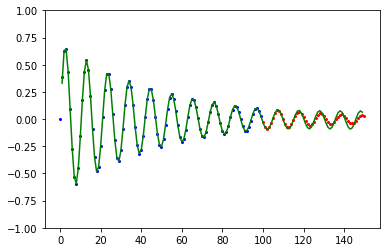

63100 3.464733997950453e-05 0.011540312447830024


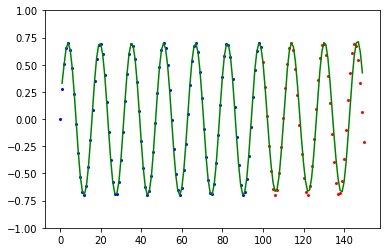

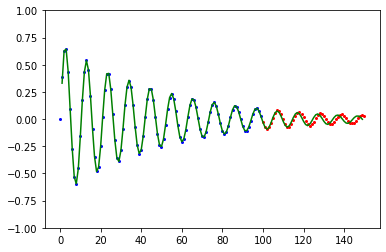

69700 3.642783734274589e-05 0.015145295790106763


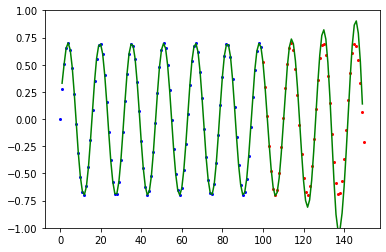

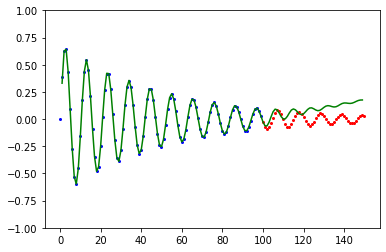

72400 3.349392012244568e-05 0.007833392866219605


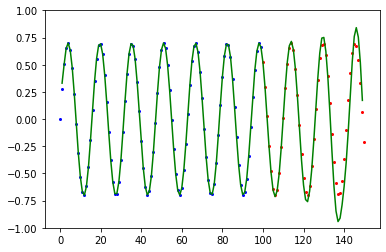

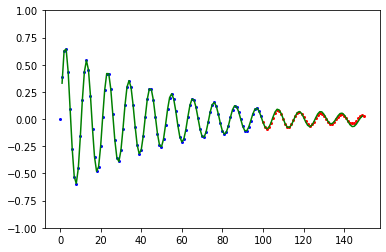

75500 3.437640886623051e-05 0.0005356495590584984


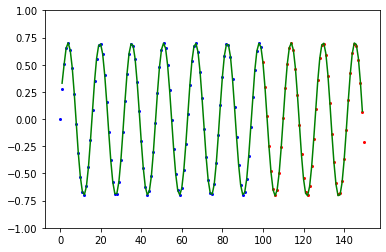

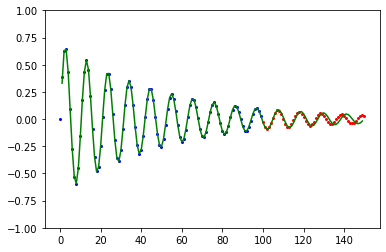

85900 3.457499479139097e-05 0.0020875381571635863


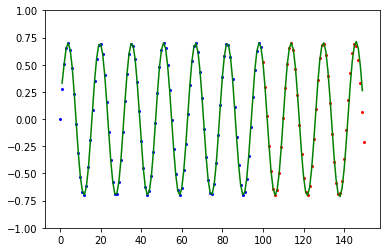

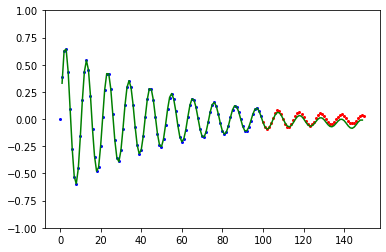

88300 0.011152221726404638 0.0016670418567667385


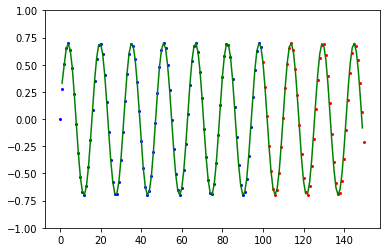

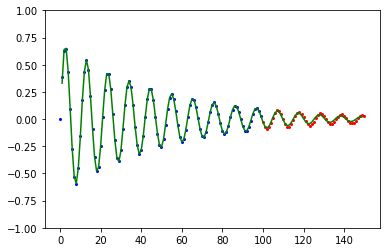

94700 3.475833128617792e-05 0.0005137341746263473


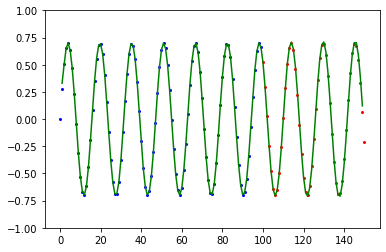

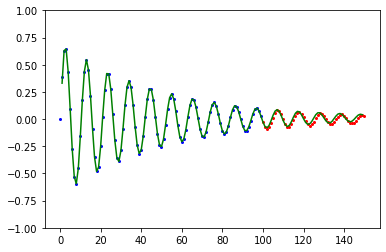

103500 3.420457047743622e-05 0.0002560245831110562


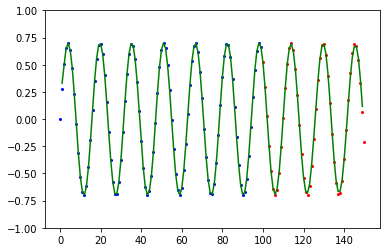

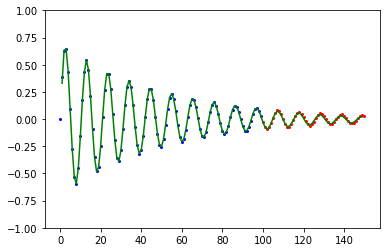

108800 3.423655236288432e-05 0.0003600654126893246


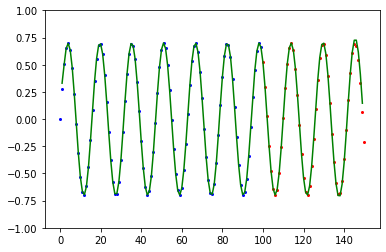

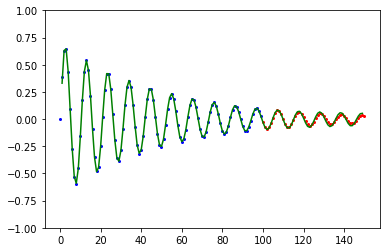

113100 3.326722231091914e-05 0.00010971512307488777


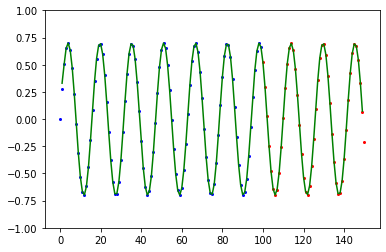

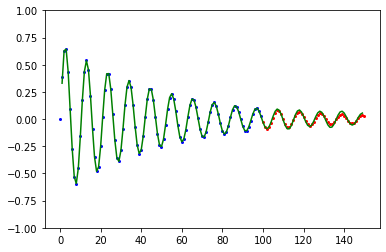

118000 3.4583793796406296e-05 0.003000022018050484


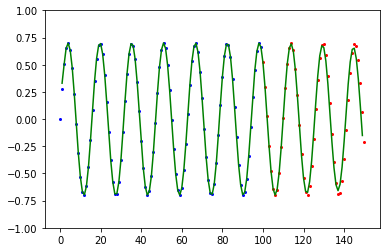

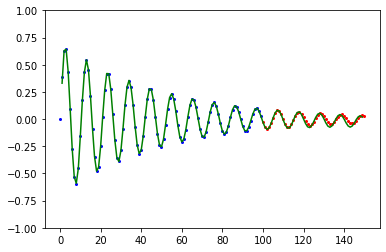

121100 3.3341497514064287e-05 0.00018005345864955232


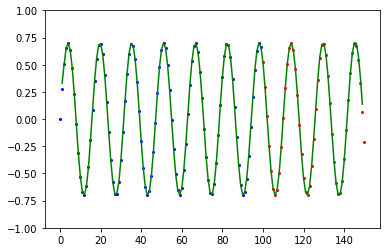

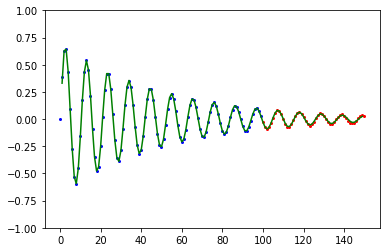

130200 3.734521777382062e-05 0.0014126543989913482


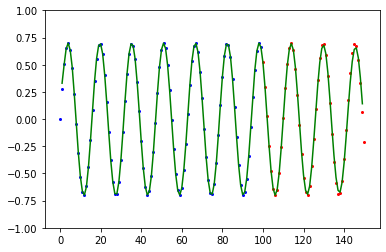

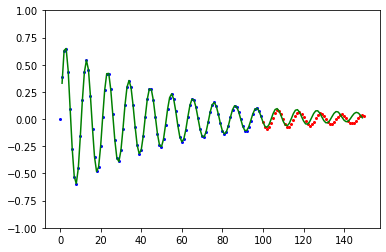

134700 3.3308843468265346e-05 0.00023930470609161727


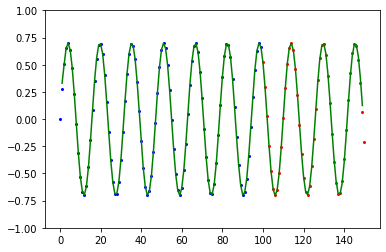

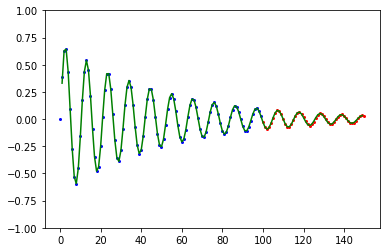

138700 3.464470055587697e-05 8.45314759906369e-05


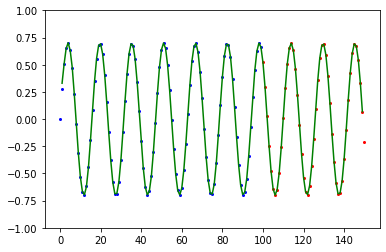

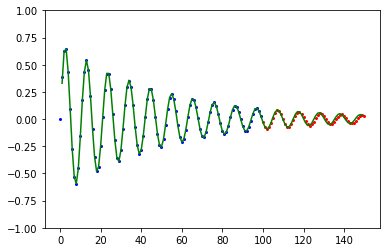

143300 3.353230192204399e-05 0.0003728132188879285


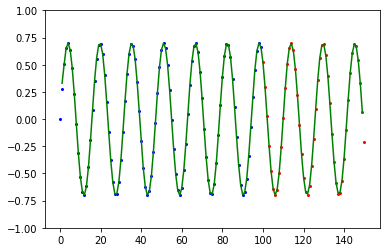

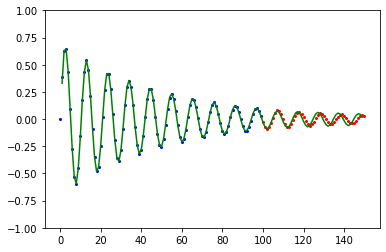

149000 3.3414673585039846e-05 0.8793242019944252


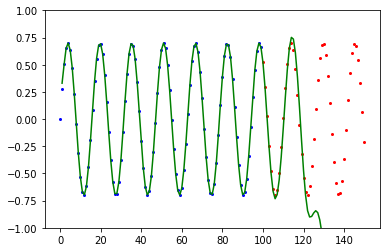

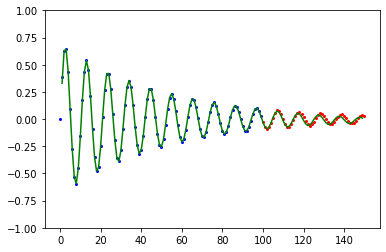

152300 3.3588029775085864e-05 0.000561971381670209


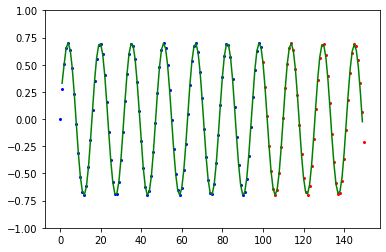

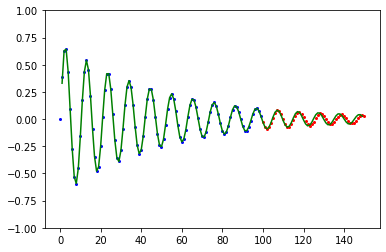

155100 3.418054596043998e-05 0.00029268429901469547


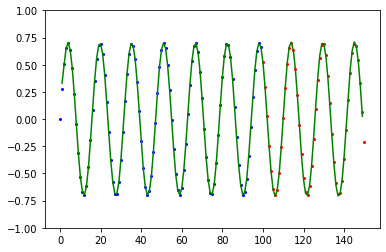

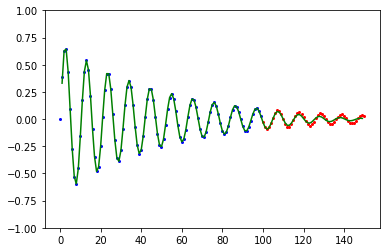

157500 3.387431554980681e-05 0.00016520842035166745


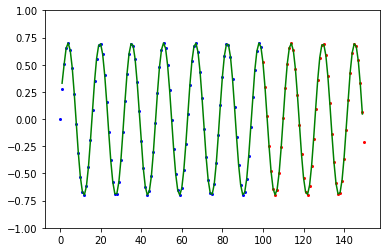

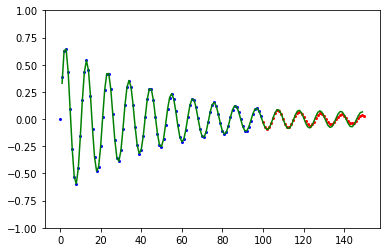

161700 3.3324111297438145e-05 0.0013380875493781924


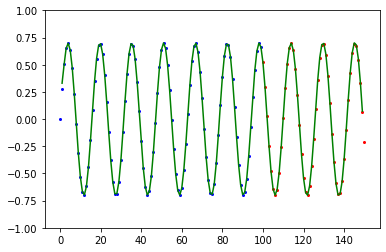

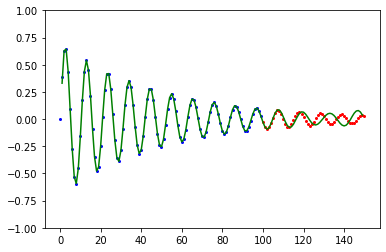

163900 3.34181373090234e-05 0.0009567219913593077


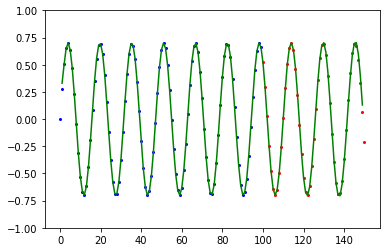

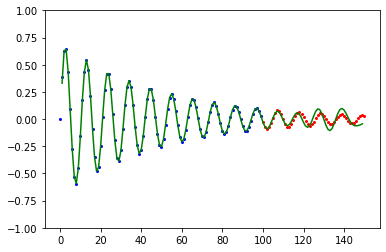

179300 3.351355311124565e-05 3.0823092631548895e-05


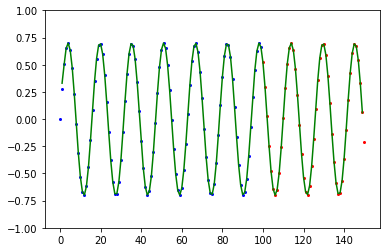

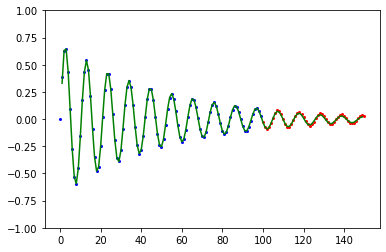

184300 3.3899458041972734e-05 0.0002083002549153739


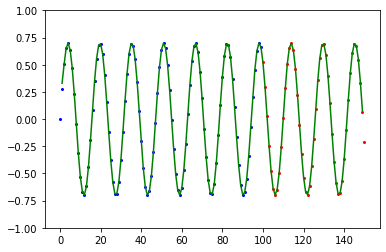

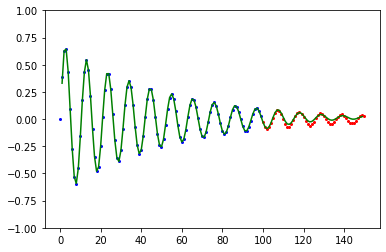

188900 3.3838527329934314e-05 0.016881672550379808


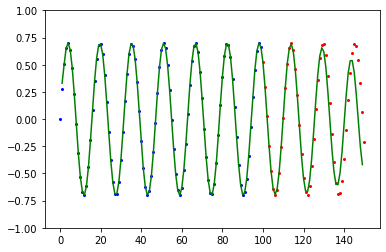

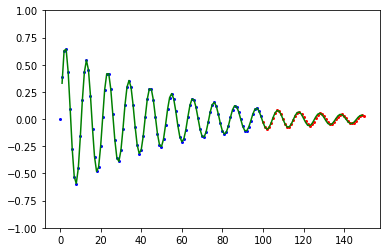

192900 3.382073540695165e-05 2.2358624054805788e-05


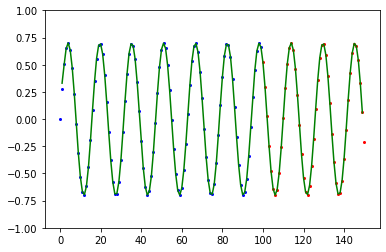

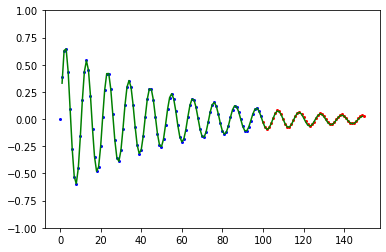

193400 0.04013973826658978 0.33219365392542877


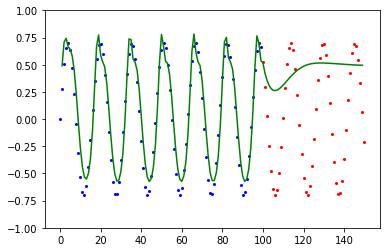

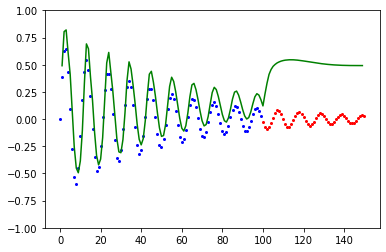

196600 3.49656766432055e-05 0.002500916603246401


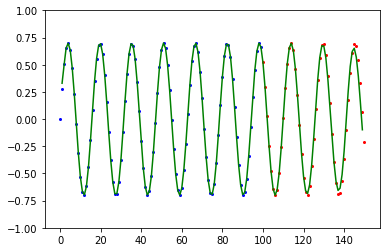

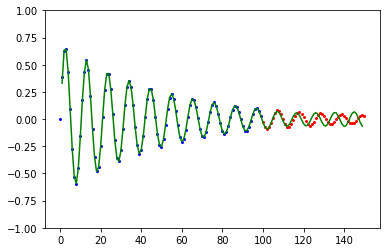

201200 3.35931745798958e-05 0.0014954093743300891


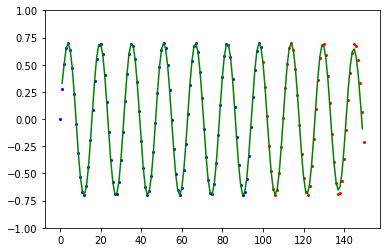

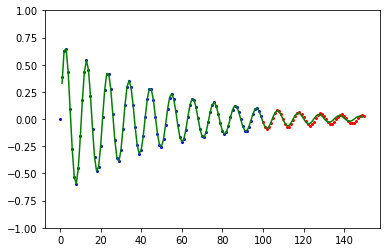

205300 3.387681993167514e-05 0.0317168930881243


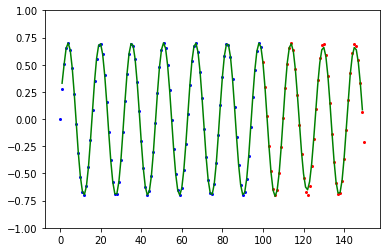

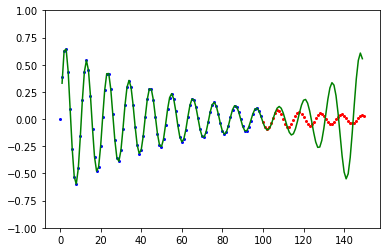

210700 3.307413767193646e-05 0.002137957858616643


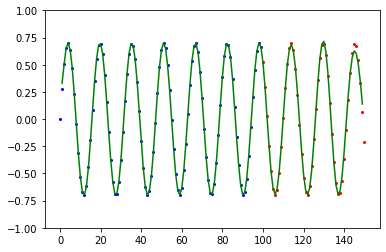

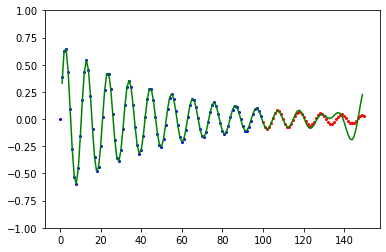

212700 0.027461837039944207 0.0009503959564691083


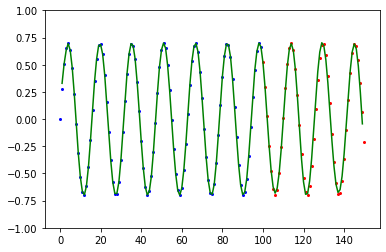

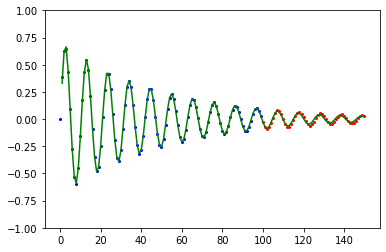

217300 3.399656169681536e-05 0.15518918999184442


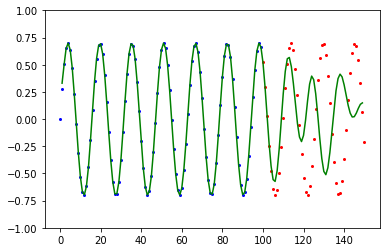

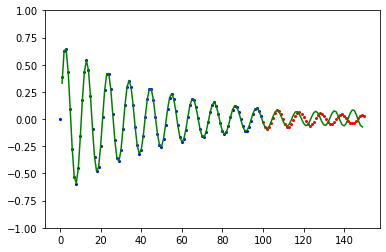

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.03582024, dtype=float64)

In [35]:
len(test_result)

50